# Customer Churn Prediction

**Dataset:** Telco Customer Churn  
**Source:** [Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
**Author:** Bicher A

## Objective
Building a machine learning model to predict which telecom customers 
are likely to cancel their subscription, and identify the key 
drivers of churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Cell 2 — Data Cleaning

# Check missing values
print("Missing values:")
print(df.isnull().sum())

# TotalCharges has hidden spaces —> convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many became NaN
print("\nTotalCharges nulls after conversion:", df['TotalCharges'].isnull().sum())

# Drop those rows 
df = df.dropna(subset=['TotalCharges'])

# Convert Churn to binary 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}).copy()

# Convert SeniorCitizen is already 0/1
# Drop customerID —> not useful for modelling
df = df.drop(columns=['customerID'])

print("\nCleaned shape:", df.shape)
print("\nChurn distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].mean()*100:.1f}%")

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

TotalCharges nulls after conversion: 11

Cleaned shape: (7032, 20)

Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Churn rate: 26.6%


## 1. Exploratory Analysis
Before modelling, we explore which features are most associated with churn.

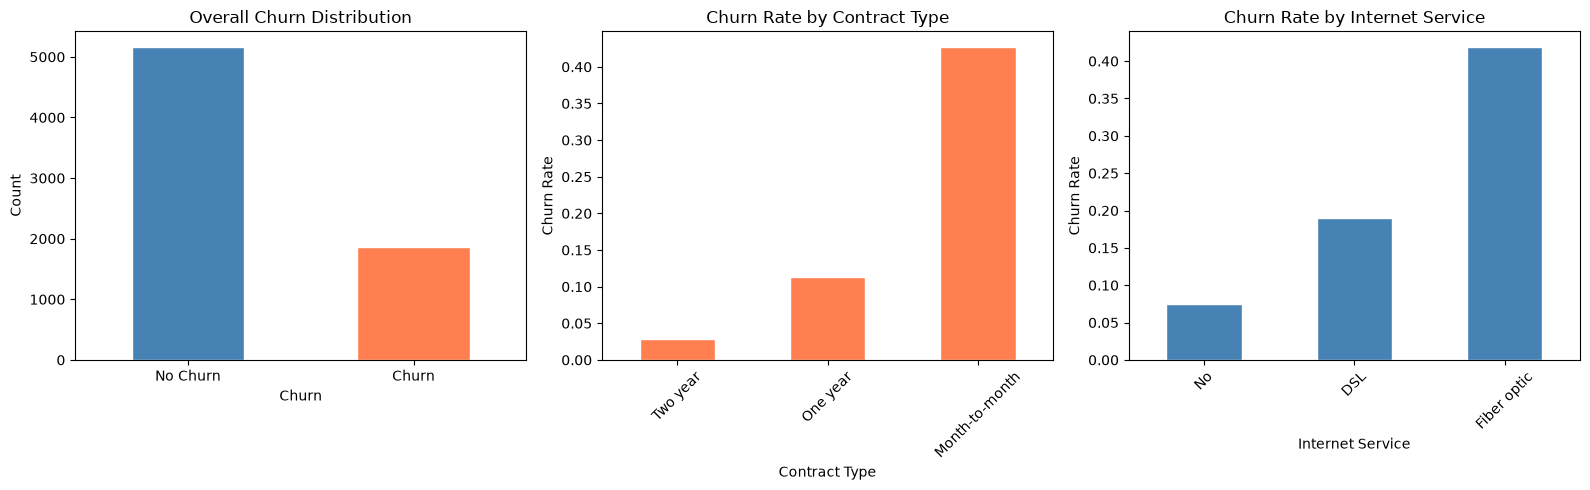

In [3]:
# Churn rate visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall churn distribution
df['Churn'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Overall Churn Distribution')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)
axes[0].set_ylabel('Count')

# Churn rate by Contract type
df.groupby('Contract')['Churn'].mean().sort_values().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Churn Rate by Contract Type')
axes[1].set_ylabel('Churn Rate')
axes[1].set_xlabel('Contract Type')
axes[1].tick_params(axis='x', rotation=45)

# Churn rate by Internet Service
df.groupby('InternetService')['Churn'].mean().sort_values().plot(
    kind='bar', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Churn Rate by Internet Service')
axes[2].set_ylabel('Churn Rate')
axes[2].set_xlabel('Internet Service')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

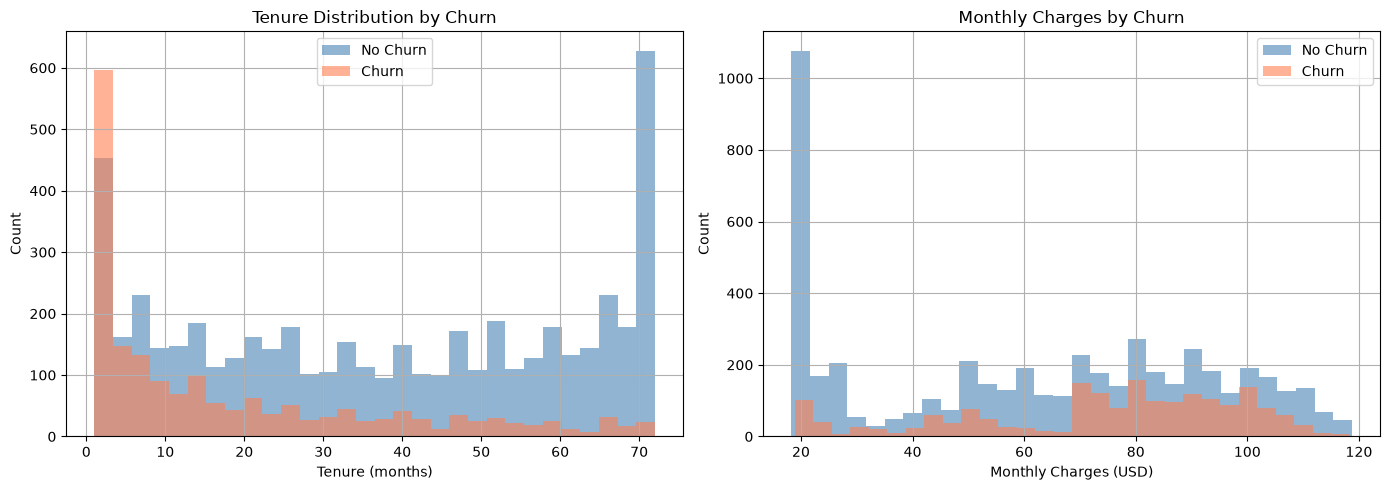

In [4]:
# Tenure and Monthly Charges vs Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure distribution by churn
df[df['Churn']==0]['tenure'].hist(
    bins=30, ax=axes[0], alpha=0.6, color='steelblue', label='No Churn')
df[df['Churn']==1]['tenure'].hist(
    bins=30, ax=axes[0], alpha=0.6, color='coral', label='Churn')
axes[0].set_title('Tenure Distribution by Churn')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Monthly charges distribution by churn
df[df['Churn']==0]['MonthlyCharges'].hist(
    bins=30, ax=axes[1], alpha=0.6, color='steelblue', label='No Churn')
df[df['Churn']==1]['MonthlyCharges'].hist(
    bins=30, ax=axes[1], alpha=0.6, color='coral', label='Churn')
axes[1].set_title('Monthly Charges by Churn')
axes[1].set_xlabel('Monthly Charges (USD)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. Feature Engineering
Converting categorical variables to numeric format for modelling.
Binary Yes/No columns use label encoding. Multi-category columns 
use one-hot encoding to avoid implying false ordering.

In [5]:
from sklearn.preprocessing import LabelEncoder

# Step 1 — Label encode binary Yes/No columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV',
               'StreamingMovies', 'PaperlessBilling']

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Step 2 — One-hot encode multi-category columns
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'],
                    drop_first=True)

# Step 3 — Check the result
print("Shape after encoding:", df.shape)
print("\nColumn list:")
print(df.columns.tolist())
print("\nSample of encoded data:")
df.head(3)

Shape after encoding: (7032, 24)

Column list:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Sample of encoded data:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,0,2,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,2,0,2,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,2,2,0,...,53.85,108.15,1,False,False,False,False,False,False,True


## 3. Modelling
starting with Logistic Regression as a simple, interpretable baseline,
then compare with Random Forest. We use an 80/20 train/test split.
80% of data trains the model, 20% is held back to evaluate it on 
unseen data, simulating real-world performance.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler

# Separate features (X) from target (y)
# X = everything the model learns from
# y = what we're trying to predict (Churn)
X = df.drop(columns=['Churn'])
y = df['Churn']

# Split into training and test sets
# random_state=42 means the split is reproducible — same split every run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print(f"Churn rate in training set: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test set: {y_test.mean()*100:.1f}%")

# Scale features — Logistic Regression needs this because it's sensitive
# to features being on very different scales (tenure 0-72 vs charges 0-120)
# Random Forest doesn't need scaling but we apply it anyway for consistency
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # use same scaler fitted on training data

Training set size: (5625, 23)
Test set size: (1407, 23)
Churn rate in training set: 26.6%
Churn rate in test set: 26.6%


In [7]:
# Train Logistic Regression
# max_iter=1000 — gives the model enough iterations to converge
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Train Random Forest
# n_estimators=100 — builds 100 decision trees and combines them
# This is the industry standard starting point
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Compare results
print("=" * 45)
print("LOGISTIC REGRESSION")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(y_test, lr_preds)*100:.1f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, lr_proba):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=['No Churn', 'Churn']))

print("=" * 45)
print("RANDOM FOREST")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(y_test, rf_preds)*100:.1f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_proba):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=['No Churn', 'Churn']))

LOGISTIC REGRESSION
Accuracy:  78.9%
ROC-AUC:   0.832

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1033
       Churn       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

RANDOM FOREST
Accuracy:  78.5%
ROC-AUC:   0.815

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.82      0.90      0.86      1033
       Churn       0.63      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



## 4. Model Evaluation
Visualising model performance with a confusion matrix and ROC curve.
Accuracy alone is misleading on imbalanced datasets so we focus on 
ROC-AUC and recall for the churn class.

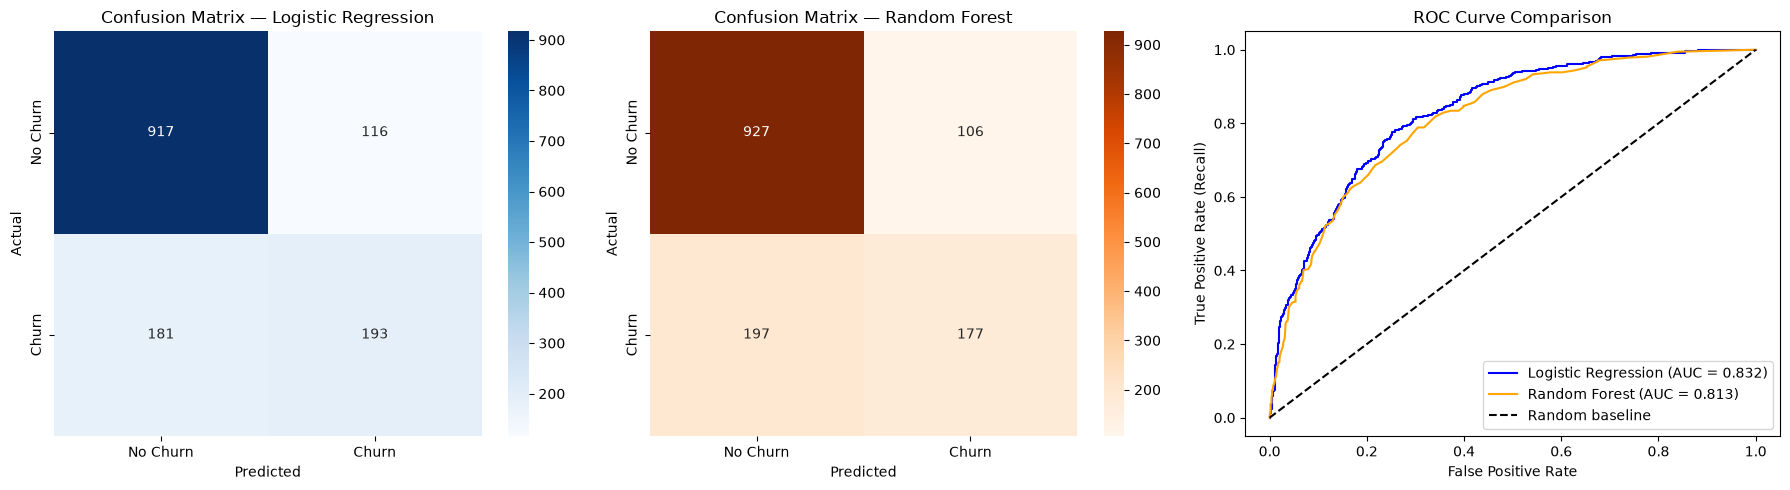

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix — Logistic Regression
cm_lr = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Confusion Matrix — Logistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Confusion Matrix — Random Forest
cm_rf = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[1].set_title('Confusion Matrix — Random Forest')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# ROC Curve — both models on same chart for comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

axes[2].plot(fpr_lr, tpr_lr, color='blue', 
             label=f'Logistic Regression (AUC = 0.832)')
axes[2].plot(fpr_rf, tpr_rf, color='orange', 
             label=f'Random Forest (AUC = 0.813)')
axes[2].plot([0,1], [0,1], 'k--', label='Random baseline')
axes[2].set_title('ROC Curve Comparison')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate (Recall)')
axes[2].legend()

plt.tight_layout()
plt.show()

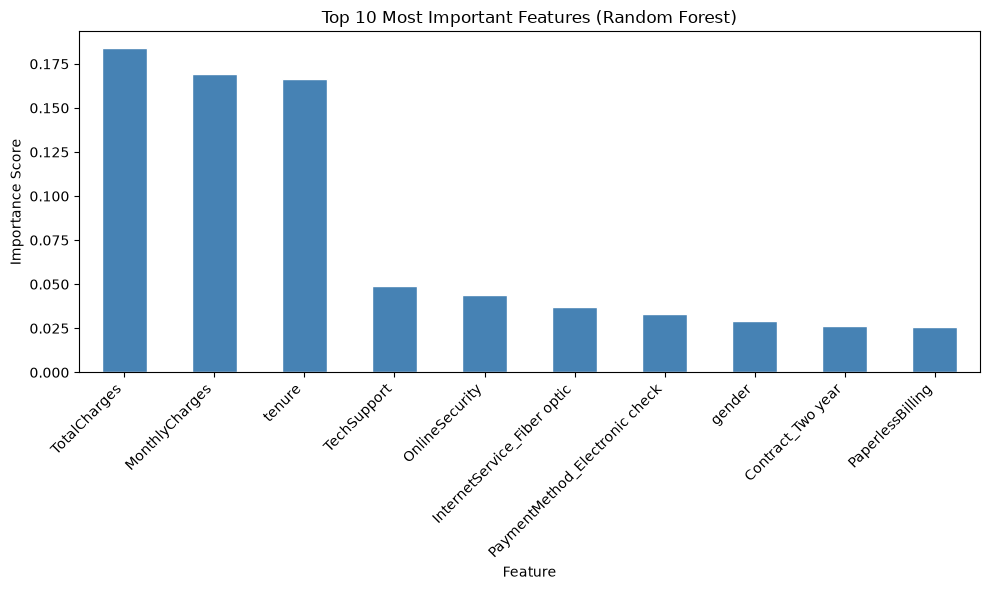

Top 10 features:
TotalCharges                      0.184249
MonthlyCharges                    0.169153
tenure                            0.166360
TechSupport                       0.048860
OnlineSecurity                    0.044037
InternetService_Fiber optic       0.037344
PaymentMethod_Electronic check    0.032931
gender                            0.029219
Contract_Two year                 0.026377
PaperlessBilling                  0.025747
dtype: float64


In [9]:
# Feature importance from Random Forest
# This tells us which features the model relied on most
feature_importance = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(feature_importance)

## 5. XGBoost Model
XGBoost (Extreme Gradient Boosting) is added as a third model. 
Unlike Random Forest which builds trees independently in parallel, 
XGBoost builds trees sequentially — each tree learns from the 
mistakes of the previous one. This often produces better results 
on structured tabular data.

In [10]:
from xgboost import XGBClassifier

# Train XGBoost
# use_label_encoder=False and eval_metric suppress warnings
# scale_pos_weight handles our class imbalance — tells the model
# to weight churners more heavily since they're the minority class
# We calculate it as ratio of non-churners to churners
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale pos weight: {scale:.2f}")

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=scale,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)
xgb_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("=" * 45)
print("XGBOOST")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(y_test, xgb_preds)*100:.1f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, xgb_proba):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds, target_names=['No Churn', 'Churn']))

Scale pos weight: 2.76
XGBOOST
Accuracy:  73.1%
ROC-AUC:   0.800

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.77      0.81      1033
       Churn       0.50      0.63      0.55       374

    accuracy                           0.73      1407
   macro avg       0.67      0.70      0.68      1407
weighted avg       0.76      0.73      0.74      1407



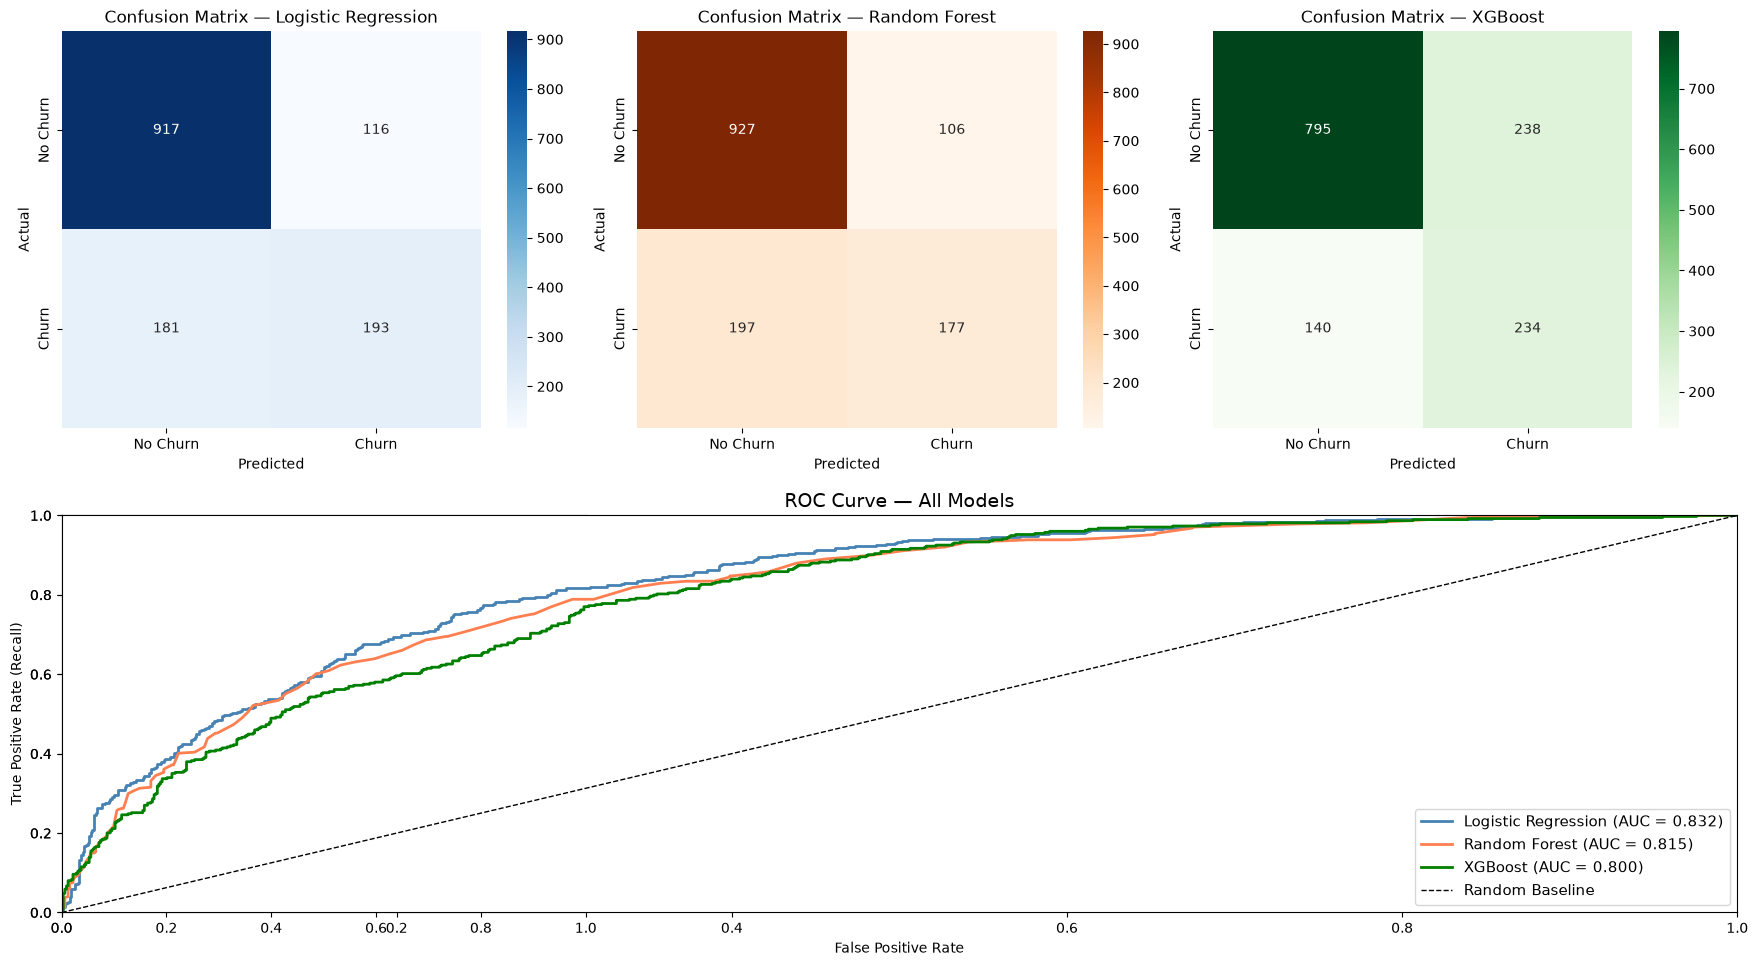

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Confusion Matrices (top row) ---
models = [
    ('Logistic Regression', lr_preds, 'Blues'),
    ('Random Forest', rf_preds, 'Oranges'),
    ('XGBoost', xgb_preds, 'Greens')
]

for i, (name, preds, cmap) in enumerate(models):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[0][i],
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    axes[0][i].set_title(f'Confusion Matrix — {name}')
    axes[0][i].set_ylabel('Actual')
    axes[0][i].set_xlabel('Predicted')

# --- ROC Curves (bottom row, spanning all 3) ---
# Merge bottom row into one wide chart
for ax in axes[1][1:]:
    ax.set_visible(False)

ax_roc = axes[1][0]
fig.add_subplot(2, 1, 2)
ax_roc = fig.axes[-1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)

ax_roc.plot(fpr_lr, tpr_lr, color='steelblue', linewidth=2,
            label=f'Logistic Regression (AUC = 0.832)')
ax_roc.plot(fpr_rf, tpr_rf, color='coral', linewidth=2,
            label=f'Random Forest (AUC = 0.815)')
ax_roc.plot(fpr_xgb, tpr_xgb, color='green', linewidth=2,
            label=f'XGBoost (AUC = 0.800)')
ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline')
ax_roc.set_title('ROC Curve — All Models', fontsize=14)
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate (Recall)')
ax_roc.legend(loc='lower right', fontsize=11)
ax_roc.set_xlim([0, 1])
ax_roc.set_ylim([0, 1])

plt.tight_layout()
plt.show()

## 6. Key Findings

| # | Theme | Finding |
|---|-------|---------|
| 1 | Churn Rate | 26.6% of customers churned — roughly 1 in 4. The dataset is imbalanced so accuracy alone is a misleading metric. |
| 2 | Contract Type | Month-to-month customers churn at 42% vs just 3% for two-year contracts. Contract length is the single strongest business lever for reducing churn. |
| 3 | Tenure | Customers who churn overwhelmingly do so in the first 10 months. Early intervention and onboarding programmes could significantly reduce churn. |
| 4 | Monthly Charges | Higher-paying customers churn more — suggesting price sensitivity is a key driver, particularly among Fiber optic users. |
| 5 | Model Selection | Logistic Regression achieved the best ROC-AUC (0.832) showing that simpler models can outperform complex ones on clean structured data. XGBoost achieved the best churn recall (0.626) making it preferable if the business priority is catching as many churners as possible. |
| 6 | Top Features | TotalCharges, MonthlyCharges and tenure were the three most important features — all related to how long a customer has been with the company and how much they pay. |

In [11]:
# model comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, xgb_proba)
    ],
    'Churn Recall': [
        classification_report(y_test, lr_preds, output_dict=True)['1']['recall'],
        classification_report(y_test, rf_preds, output_dict=True)['1']['recall'],
        classification_report(y_test, xgb_preds, output_dict=True)['1']['recall']
    ]
}).round(3)

print(results.to_string(index=False))

              Model  Accuracy  ROC-AUC  Churn Recall
Logistic Regression     0.789    0.832         0.516
      Random Forest     0.785    0.815         0.473
            XGBoost     0.731    0.800         0.626


In [12]:
print("Project Summary:")
print(f"  Total customers analysed: {len(df):,}")
print(f"  Overall churn rate: {df['Churn'].mean()*100:.1f}%")
print(f"  Features used for modelling: {X.shape[1]}")
print(f"  Best ROC-AUC: 0.832 (Logistic Regression)")
print(f"  Best Churn Recall: 0.626 (XGBoost)")
print(f"  Recommended model: XGBoost (maximises churner detection)")

Project Summary:
  Total customers analysed: 7,032
  Overall churn rate: 26.6%
  Features used for modelling: 23
  Best ROC-AUC: 0.832 (Logistic Regression)
  Best Churn Recall: 0.626 (XGBoost)
  Recommended model: XGBoost (maximises churner detection)
